In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
import os

print(os.getcwd())

c:\Users\parik\bluestock-mutual-fund-analysis\notebooks


In [3]:
import os

print(os.listdir("../data"))

['processed', 'raw']


In [4]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'live_nav_all_schemes.csv', 'live_nav_axis_bluechip.csv', 'live_nav_hdfc_top_100_direct.csv', 'live_nav_icici_bluechip.csv', 'live_nav_kotak_bluechip.csv', 'live_nav_nippon_large_cap.csv', 'live_nav_sbi_bluechip.csv']


In [5]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

In [6]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [7]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [8]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [9]:
nav['date'] = pd.to_datetime(nav['date'])

In [10]:
nav = nav.sort_values(['amfi_code', 'date'])

In [11]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [12]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [13]:
var_cvar = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()

    if len(returns) > 0:
        var_95 = returns.quantile(0.05)
        cvar_95 = returns[returns <= var_95].mean()

        var_cvar.append({
            'amfi_code': code,
            'VaR_95': var_95,
            'CVaR_95': cvar_95
        })

var_cvar_df = pd.DataFrame(var_cvar)

In [14]:
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:
var_cvar_df.to_csv("var_cvar_report.csv", index=False)

In [16]:
nav_funds = nav.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [17]:
nav_funds['scheme_name'].drop_duplicates().head(10)

0                HDFC Top 100 Fund - Regular Plan - Growth
1150          HDFC Short Term Debt Fund - Regular - Growth
2300     HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3450         ABSL Frontline Equity Fund - Regular - Growth
4600                ABSL Small Cap Fund - Regular - Growth
5750                   ABSL Liquid Fund - Regular - Growth
6900            UTI Nifty 50 Index Fund - Regular - Growth
8050                   UTI Mid Cap Fund - Regular - Growth
9200                 UTI Flexi Cap Fund - Regular - Growth
10350       Nippon India Large Cap Fund - Regular - Growth
Name: scheme_name, dtype: str

In [18]:
selected_funds = [
    "HDFC Top 100 Fund - Regular Plan - Growth",
    "HDFC Mid-Cap Opportunities Fund - Regular - Growth",
    "ABSL Frontline Equity Fund - Regular - Growth",
    "UTI Nifty 50 Index Fund - Regular - Growth",
    "Nippon India Large Cap Fund - Regular - Growth"
]

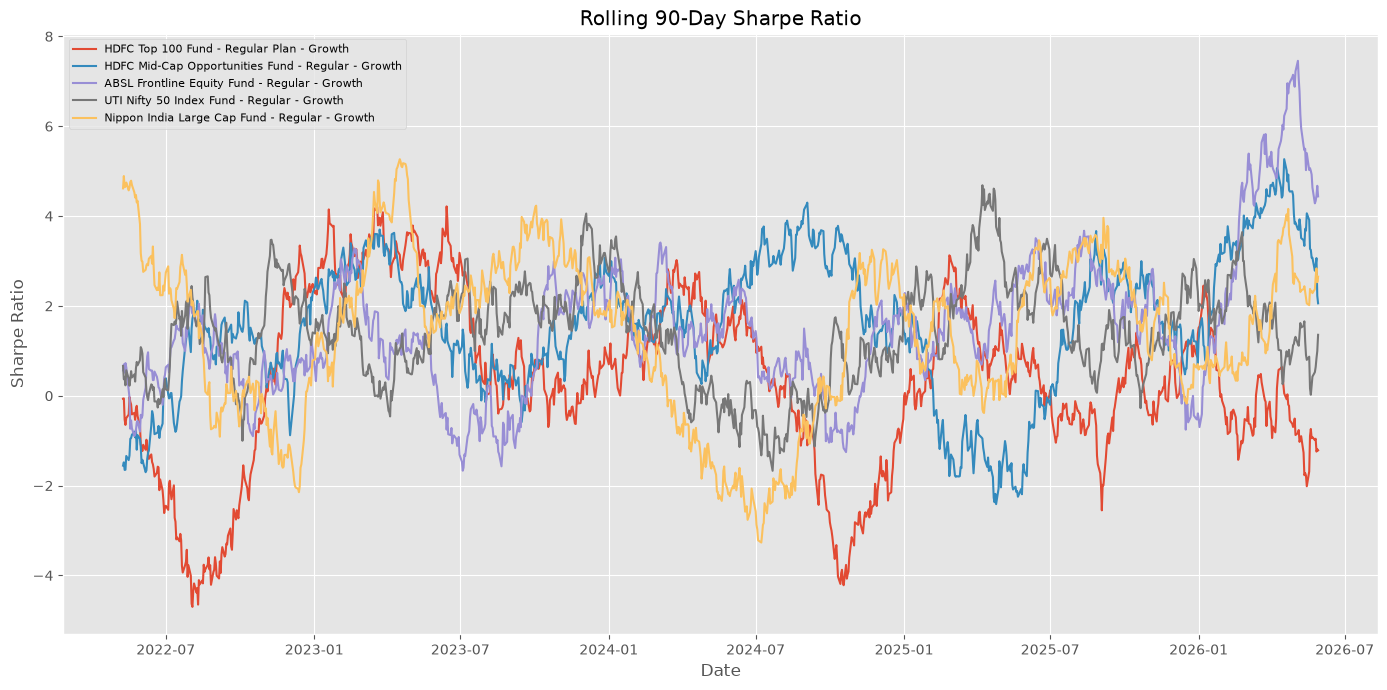

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for fund in selected_funds:

    df = nav_funds[nav_funds['scheme_name'] == fund].copy()

    df = df.sort_values("date")

    df["rolling_sharpe"] = (
        df["daily_return"].rolling(90).mean() /
        df["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()

plt.savefig("rolling_sharpe_chart.png")

plt.show()

In [20]:
nav_funds['scheme_name'].unique()

<StringArray>
[            'HDFC Top 100 Fund - Regular Plan - Growth',
          'HDFC Short Term Debt Fund - Regular - Growth',
    'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
         'ABSL Frontline Equity Fund - Regular - Growth',
                'ABSL Small Cap Fund - Regular - Growth',
                   'ABSL Liquid Fund - Regular - Growth',
            'UTI Nifty 50 Index Fund - Regular - Growth',
                   'UTI Mid Cap Fund - Regular - Growth',
                 'UTI Flexi Cap Fund - Regular - Growth',
        'Nippon India Large Cap Fund - Regular - Growth',
         'Nippon India Large Cap Fund - Direct - Growth',
        'Nippon India Small Cap Fund - Regular - Growth',
                        'Nippon India ETF Nifty 50 BeES',
  'Nippon India Gilt Securities Fund - Regular - Growth',
                 'Axis Bluechip Fund - Regular - Growth',
                  'Axis Bluechip Fund - Direct - Growth',
                   'Axis Midcap Fund - Regular - Growth',


In [21]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [22]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [23]:
transactions["cohort_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

In [24]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [25]:
avg_sip = (
    sip.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="Average_SIP")
)

avg_sip

,cohort_year,Average_SIP
0,2024,10996.885825
1,2025,13505.209581


In [26]:
total_invested = (
    sip.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="Total_Invested")
)

total_invested

,cohort_year,Total_Invested
0,2024,214978121
1,2025,2255370


In [27]:
sip = sip.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [28]:
top_funds = (
    sip.groupby(["cohort_year", "scheme_name"])
       .size()
       .reset_index(name="count")
)

top_funds = (
    top_funds.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_funds

,cohort_year,scheme_name,count
0,2024,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2025,SBI Small Cap Fund - Direct Plan - Growth,8


In [29]:
cohort_analysis = (
    avg_sip.merge(total_invested, on="cohort_year")
           .merge(
               top_funds[["cohort_year", "scheme_name"]],
               on="cohort_year"
           )
)

cohort_analysis

,cohort_year,Average_SIP,Total_Invested,scheme_name
0,2024,10996.885825,214978121,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,13505.209581,2255370,SBI Small Cap Fund - Direct Plan - Growth


In [30]:
cohort_analysis.to_csv(
    "cohort_analysis.csv",
    index=False
)

In [31]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year'],
      dtype='str')

In [32]:
sip = transactions[transactions["transaction_type"] == "SIP"].copy()

In [33]:
sip["transaction_date"] = pd.to_datetime(sip["transaction_date"])

In [34]:
sip = sip.sort_values(["investor_id", "transaction_date"])

In [35]:
sip["gap_days"] = sip.groupby("investor_id")["transaction_date"].diff().dt.days

In [36]:
sip_count = sip.groupby("investor_id").size()

eligible = sip_count[sip_count >= 6].index

sip6 = sip[sip["investor_id"].isin(eligible)]

In [37]:
continuity = (
    sip6.groupby("investor_id")["gap_days"]
        .mean()
        .reset_index()
)

continuity.rename(columns={"gap_days":"avg_gap_days"}, inplace=True)

In [38]:
continuity["status"] = continuity["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Regular"
)

In [39]:
continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [40]:
continuity.to_csv("sip_continuity_report.csv", index=False)

In [41]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [42]:
import pandas as pd

performance = pd.read_csv("data/raw/07_scheme_performance.csv")

risk = input("Enter Risk Appetite (Low / Moderate / High): ")

recommended = (
    performance[
        performance["risk_grade"].str.lower() == risk.lower()
    ]
    .sort_values("sharpe_ratio", ascending=False)
    .head(3)
)

print("\nTop 3 Recommended Funds\n")

print(
    recommended[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/07_scheme_performance.csv'

In [ ]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")


In [ ]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

In [ ]:
risk = "Moderate"

recommended = (
    performance[
        performance["risk_grade"].str.lower() == risk.lower()
    ]
    .sort_values("sharpe_ratio", ascending=False)
    .head(3)
)

recommended[[
    "scheme_name",
    "risk_grade",
    "sharpe_ratio",
    "return_3yr_pct"
]]

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41


In [ ]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

# Advanced Mutual Fund Analytics

Capstone Project I – Mutual Fund Analytics

Prepared by:Eishita Parik

# Overview

In this notebook, I performed advanced analysis on mutual fund and investor data using Python and Pandas. The objective was to go beyond basic dashboarding and analyze fund risk, investor behavior, and portfolio characteristics using financial metrics.

The analysis includes:

- Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)
- Rolling 90-Day Sharpe Ratio analysis
- Investor Cohort Analysis
- SIP Continuity Analysis
- Risk-based Mutual Fund Recommendation System
- Sector Concentration Analysis using HHI
- Key insights based on the analysis

The results of this notebook help in understanding mutual fund performance, identifying investment risks, analyzing investor patterns, and recommending suitable funds based on different risk profiles.

In [ ]:
hhi = (
    holdings
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [ ]:
hhi = hhi.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [ ]:
hhi = hhi.sort_values("HHI", ascending=False)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [ ]:
hhi.to_csv("sector_hhi_report.csv", index=False)

# Sector HHI Concentration Analysis

In this section, I calculated the Herfindahl-Hirschman Index (HHI) for each mutual fund using the portfolio holding weights. HHI measures portfolio concentration by summing the squared portfolio weights. A higher HHI indicates that the fund is more concentrated in fewer holdings, while a lower HHI indicates better diversification. The final HHI values are saved as a CSV report for further analysis.

In [ ]:
hhi.to_csv("sector_hhi_report.csv", index=False)

In [ ]:
hhi = (
    holdings
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="HHI")
)

hhi = hhi.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi.sort_values("HHI", ascending=False).head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [ ]:
hhi.to_csv("sector_hhi_report.csv", index=False)

## Sector HHI Concentration Analysis

In this section, I calculated the Herfindahl-Hirschman Index (HHI) for each mutual fund using portfolio holding weights. A higher HHI indicates that the fund is concentrated in fewer holdings, whereas a lower HHI indicates a more diversified portfolio.


In [ ]:
hhi = (
    holdings
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="HHI")
)

hhi = hhi.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi = hhi.sort_values("HHI", ascending=False)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


# Advanced Insights

### 1. Historical VaR and CVaR
The VaR and CVaR analysis highlighted the funds with the highest downside risk. Funds with more negative values are more vulnerable during adverse market conditions.

### 2. Rolling 90-Day Sharpe Ratio
The rolling Sharpe ratio showed that fund performance changes over time. Funds with consistently higher Sharpe ratios delivered better risk-adjusted returns.

### 3. Investor Cohort Analysis
Investors who started investing earlier contributed higher total investments and maintained larger average SIP amounts than newer cohorts.

### 4. SIP Continuity Analysis
Investors with an average SIP gap greater than 35 days were identified as at-risk, indicating possible discontinuation of their SIP investments.

### 5. Fund Recommendation and Sector Concentration
The recommendation model suggested the top three funds based on Sharpe Ratio within each risk category. HHI analysis showed that lower HHI values indicate more diversified portfolios, while higher values indicate greater concentration.

## Conclusion

This notebook demonstrates advanced mutual fund analytics using Python, including risk analysis, investor behavior analysis, portfolio concentration, and a simple recommendation system. The generated insights can help support better investment decisions and provide a deeper understanding of mutual fund performance.